# Task 1: Potential Problems in Linear Regression

This notebook explores three common issues in linear regression, correlation of error terms, outliers, and high-leverage points, based on Section 3.3.3 of *An Introduction to Statistical Learning with Applications in Python*.

## 

## Issue 1: Correlation of Error Terms
Correlation of error terms happens when the model’s errors are related to each other instead of being independent. This often happens with time-based data, where one error may be similar to the next one. It matters because the model can appear more confident than it really is, leading to confidence intervals that are too narrow and p-values that are too small. A good way to detect this is to plot the residuals over time and look for patterns. 

* Question: Does the correlation of error terms change the regression line itself? 

    * After looking into it, I learned that the line may still look reasonable, but the uncertainty and significance results can be misleading.

Following is the code from *Claude.ai*:

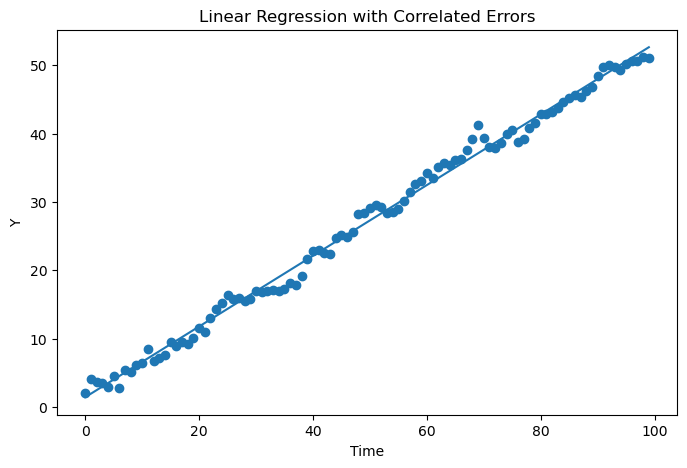

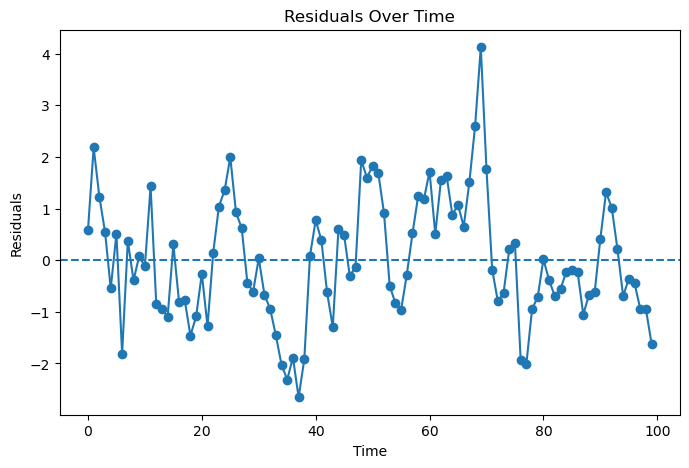

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

np.random.seed(1)

n = 100
x = np.arange(n)

# Create correlated errors
errors = np.zeros(n)
rho = 0.8

for i in range(1, n):
    errors[i] = rho * errors[i-1] + np.random.normal(0, 1)

# Create response variable
y = 2 + 0.5 * x + errors

# Fit linear regression model
X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
fitted = model.fittedvalues
residuals = model.resid

# Plot data and regression line
plt.figure(figsize=(8, 5))
plt.scatter(x, y)
plt.plot(x, fitted)
plt.xlabel("Time")
plt.ylabel("Y")
plt.title("Linear Regression with Correlated Errors")
plt.show()

# Plot residuals over time
plt.figure(figsize=(8, 5))
plt.plot(x, residuals, marker="o")
plt.axhline(0, linestyle="--")
plt.xlabel("Time")
plt.ylabel("Residuals")
plt.title("Residuals Over Time")
plt.show()

The first plot shows a linear regression fit to time-based data. The second plot shows that the residuals are not randomly scattered; instead, nearby residuals tend to move together. This pattern suggests that the error terms are correlated.

## Issue 2: Outliers

An outlier is a data point whose actual value differs significantly from the model's prediction. This matters because a single unusual point can make the model’s error appear larger and affect confidence intervals, p-values, and overall model fitting. Outliers can usually be detected by looking at residual plots or studentized residuals, where values above about 3 or below -3 may be suspicious. If the outlier is clearly a data entry or measurement mistake, it may be removed, but if it is a real observation, it should be kept or studied more carefully. 

* Question: Should outliers always be deleted? 
    * I learned that they should not always be removed, as they may represent real cases or indicate that the model is missing something important.

Following is the code from *ChatGPT*:

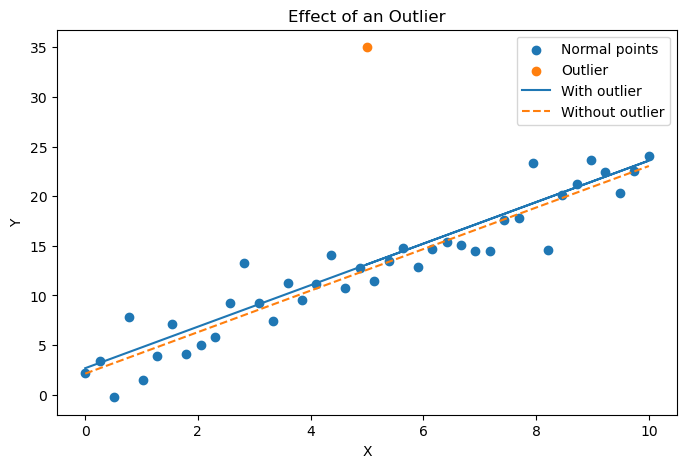

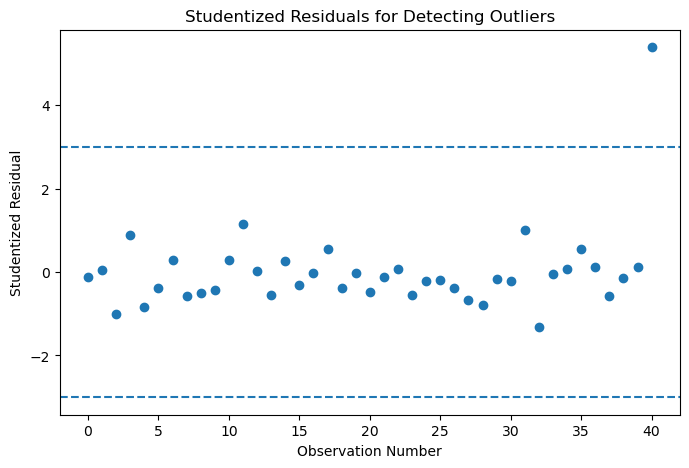

In [2]:
np.random.seed(2)

# Create mostly normal linear data
n = 40
x = np.linspace(0, 10, n)
y = 3 + 2 * x + np.random.normal(0, 2, n)

# Add one outlier
x_outlier = np.append(x, 5)
y_outlier = np.append(y, 35)

# Fit model with outlier
X_outlier = sm.add_constant(x_outlier)
model_outlier = sm.OLS(y_outlier, X_outlier).fit()

# Fit model without outlier
X_normal = sm.add_constant(x)
model_normal = sm.OLS(y, X_normal).fit()

# Plot data and regression lines
plt.figure(figsize=(8, 5))
plt.scatter(x, y, label="Normal points")
plt.scatter(5, 35, label="Outlier")
plt.plot(x_outlier, model_outlier.fittedvalues, label="With outlier")
plt.plot(x, model_normal.fittedvalues, linestyle="--", label="Without outlier")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Effect of an Outlier")
plt.legend()
plt.show()

# Plot studentized residuals
influence = model_outlier.get_influence()
studentized_residuals = influence.resid_studentized_internal

plt.figure(figsize=(8, 5))
plt.scatter(range(len(studentized_residuals)), studentized_residuals)
plt.axhline(3, linestyle="--")
plt.axhline(-3, linestyle="--")
plt.xlabel("Observation Number")
plt.ylabel("Studentized Residual")
plt.title("Studentized Residuals for Detecting Outliers")
plt.show()

The first plot shows a single point far from the rest of the data. The second plot uses studentized residuals to help identify the outlier, since values above 3 or below -3 are usually considered unusual.

## Issue 3: High-Leverage Points

A high-leverage point is a data point with an unusual x-value compared to the rest of the data. This matters because it can strongly pull the regression line toward itself, especially if it also does not follow the general pattern. High-leverage points can be detected by looking for extreme predictor values or by using the model's leverage values. A point with leverage well above the average may need closer attention. 

* Question: What makes a high-leverage point especially dangerous? 
    * The most dangerous points are both high-leverage points and outliers, as they can significantly shift the regression line and make the model misleading.

Following is the code for ChatGPT:

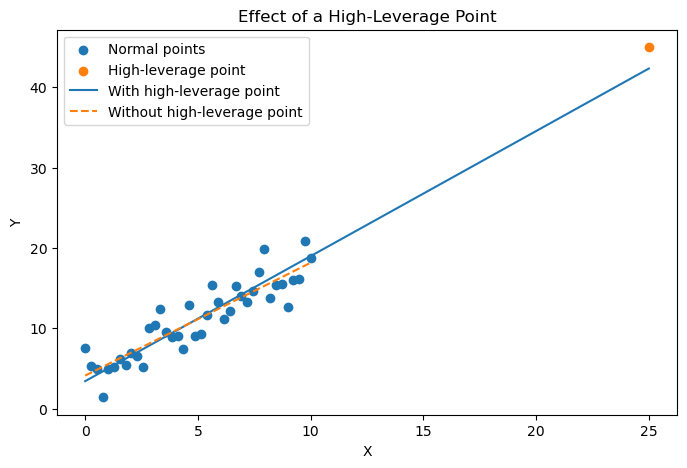

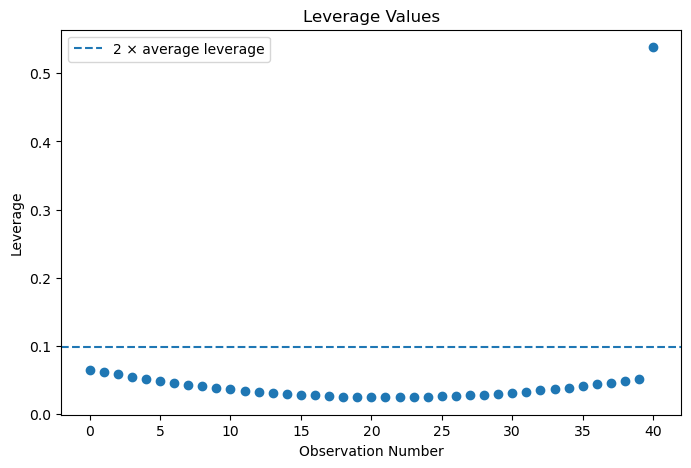

In [3]:
np.random.seed(3)

# Create normal data
n = 40
x = np.linspace(0, 10, n)
y = 4 + 1.5 * x + np.random.normal(0, 2, n)

# Add one high-leverage point
x_high = np.append(x, 25)
y_high = np.append(y, 45)

# Fit model with high-leverage point
X_high = sm.add_constant(x_high)
model_high = sm.OLS(y_high, X_high).fit()

# Fit model without high-leverage point
X_normal = sm.add_constant(x)
model_normal = sm.OLS(y, X_normal).fit()

# Plot data and regression lines
plt.figure(figsize=(8, 5))
plt.scatter(x, y, label="Normal points")
plt.scatter(25, 45, label="High-leverage point")
plt.plot(x_high, model_high.fittedvalues, label="With high-leverage point")
plt.plot(x, model_normal.fittedvalues, linestyle="--", label="Without high-leverage point")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Effect of a High-Leverage Point")
plt.legend()
plt.show()

# Plot leverage values
influence = model_high.get_influence()
leverage = influence.hat_matrix_diag

plt.figure(figsize=(8, 5))
plt.scatter(range(len(leverage)), leverage)
plt.axhline(2 * np.mean(leverage), linestyle="--", label="2 × average leverage")
plt.xlabel("Observation Number")
plt.ylabel("Leverage")
plt.title("Leverage Values")
plt.legend()
plt.show()

The first plot shows a point with an x-value far away from the rest of the data. The second plot shows that this point has much higher leverage than the other observations, indicating it can have a strong effect on the regression line.

## Generative AI Reflection:

For Task 1, I used both *ChatGPT* and *Claude.ai* to help generate Python code and explanations for each regression issue, and they generally produced very similar outputs. My prompts were simple, such as asking to “generate synthetic data and plots to show outliers” and “create an example of correlated error terms with residual plots.” It took about 2–3 iterations per issue to get code that worked correctly and produced clear visuals. There are some unclear plots that didn’t clearly highlight the issue. For example, the outlier is not being extreme enough. I identified these problems by running the code and checking whether the plots matched my expectations from the textbook. Overall, the tools were helpful for getting started, but I still had to test and modify the code to make sure it worked well.